# Summative Lab — DataVine Analytics

**Role:** Junior Data Scientist, DataVine Analytics
**Objective:** Prototype three ML solutions for boutique-consulting clients, applying a standardized workflow — data preparation, PCA-based dimensionality reduction, hyperparameter tuning, and stakeholder-ready evaluation — across three techniques:

1. **Wine Classification System** — k-Nearest Neighbors + PCA (Wine dataset)
2. **Agricultural Feed Recommendation Engine** — PCA + cosine similarity (Chickwts dataset)
3. **Regional Crime Pattern Analysis** — K-Means & Gaussian Mixture Model clustering (USArrests dataset)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


---
## Step 1: Load and Prepare Datasets

Ensure all three datasets are accessible, cleaned, and formatted correctly for machine learning applications:
load each dataset, inspect for missing values / inconsistencies, standardize numerical features, and summarize
the structure of each.


In [2]:
# Load the three datasets
wine = pd.read_csv('wine.csv')
chickwts = pd.read_csv('chickwts.csv')
usarrests = pd.read_csv('USArrests.csv').rename(columns={'rownames': 'State'})

print("Wine dataset:      ", wine.shape)
print("Chickwts dataset:  ", chickwts.shape)
print("USArrests dataset: ", usarrests.shape)


Wine dataset:       (178, 14)
Chickwts dataset:   (71, 2)
USArrests dataset:  (50, 5)


In [3]:
# --- Wine: inspect ---
print("WINE DATASET")
print(wine.info())
wine.head()


WINE DATASET
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  tar

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Missing values per column:")
print(wine.isna().sum())
print("\nDuplicate rows:", wine.duplicated().sum())
print("\nTarget class balance:")
print(wine['target'].value_counts())


Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Duplicate rows: 0

Target class balance:
target
1    71
0    59
2    48
Name: count, dtype: int64


In [5]:
# --- Chickwts: inspect ---
print("CHICKWTS DATASET")
print(chickwts.info())
chickwts.head()


CHICKWTS DATASET
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   weight  71 non-null     int64
 1   feed    71 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.2 KB
None


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [6]:
print("Missing values per column:")
print(chickwts.isna().sum())
print("\nDuplicate rows:", chickwts.duplicated().sum())
print("\nFeed type counts:")
print(chickwts['feed'].value_counts())


Missing values per column:
weight    0
feed      0
dtype: int64

Duplicate rows: 1

Feed type counts:
feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64


In [7]:
# --- USArrests: inspect ---
print("USARRESTS DATASET")
print(usarrests.info())
usarrests.head()


USARRESTS DATASET
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     50 non-null     str    
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 2.1 KB
None


,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [8]:
print("Missing values per column:")
print(usarrests.isna().sum())
print("\nDuplicate rows (excluding State):", usarrests.drop(columns='State').duplicated().sum())
usarrests.describe()


Missing values per column:
State       0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

Duplicate rows (excluding State): 0


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


**Data quality check:** none of the three datasets contain missing values, and no problematic
duplicates or inconsistencies were found. All columns are numeric except the `feed` (Chickwts) and
`State` (USArrests) identifier columns, so no further cleaning is required before modeling.

### Standardize numerical features

Standardization (zero mean, unit variance) is applied to the numerical features of each dataset so that
no single feature dominates distance- or variance-based algorithms (k-NN, PCA, K-Means, GMM all rely on
this). To avoid data leakage, the *modeling* pipelines below (Steps 2–4) fit each `StandardScaler` **only
on the relevant training/analysis data** at the point of use. Here we do a quick preview standardization
purely to confirm scaling behaves as expected.


In [9]:
# Preview standardization (Wine numeric features, excluding target)
preview_scaler = StandardScaler()
wine_scaled_preview = pd.DataFrame(
    preview_scaler.fit_transform(wine.drop(columns='target')),
    columns=wine.drop(columns='target').columns
)
print("Wine features — mean after scaling (~0):")
print(wine_scaled_preview.mean().round(2).values)
print("Wine features — std after scaling (~1):")
print(wine_scaled_preview.std().round(2).values)


Wine features — mean after scaling (~0):
[-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Wine features — std after scaling (~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
# Summary of all three datasets
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Wine:      {wine.shape[0]} samples, {wine.shape[1]-1} features, "
      f"{wine['target'].nunique()} classes")
print(f"Chickwts:  {chickwts.shape[0]} samples, 1 feature (weight), "
      f"{chickwts['feed'].nunique()} feed types")
print(f"USArrests: {usarrests.shape[0]} states, "
      f"{usarrests.shape[1]-1} numeric features")


DATASET SUMMARY
Wine:      178 samples, 13 features, 3 classes
Chickwts:  71 samples, 1 feature (weight), 6 feed types
USArrests: 50 states, 4 numeric features


---
## Step 2: k-Nearest Neighbors (k-NN) Classification on the Wine Dataset

**Client need:** a premium wine distributor wants to automatically classify wines by chemical
properties for inventory management and quality control.

**Approach:** convert target labels to numeric form, apply PCA (retaining 95% variance) to reduce
dimensionality, tune `k` and the distance metric with `GridSearchCV`, train the optimized k-NN
classifier, and evaluate it.


In [11]:
# Convert categorical target labels into numeric values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(wine['target'])
X = wine.drop(columns='target')

print("Classes:", label_encoder.classes_)
print("Encoded target sample:", y[:10])


Classes: [0 1 2]
Encoded target sample: [0 0 0 0 0 0 0 0 0 0]


In [12]:
# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (142, 13)  Test size: (36, 13)


In [13]:
# Standardize features (fit on train only, to avoid leakage)
wine_scaler = StandardScaler()
X_train_scaled = wine_scaler.fit_transform(X_train)
X_test_scaled = wine_scaler.transform(X_test)


In [14]:
# Apply PCA, retaining 95% of variance
wine_pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = wine_pca.fit_transform(X_train_scaled)
X_test_pca = wine_pca.transform(X_test_scaled)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Components retained for 95% variance: {wine_pca.n_components_}")
print(f"Cumulative variance explained: {wine_pca.explained_variance_ratio_.sum():.3f}")


Original feature count: 13
Components retained for 95% variance: 10
Cumulative variance explained: 0.962


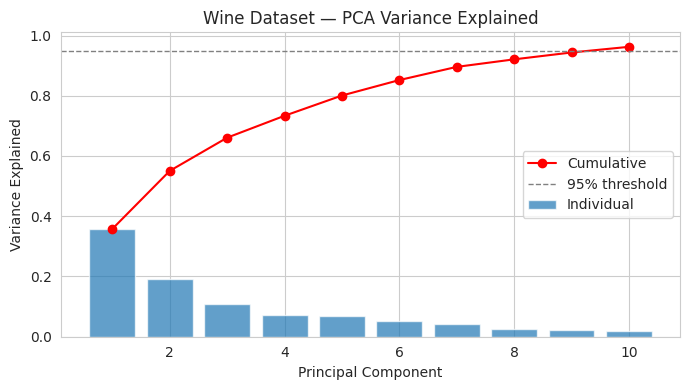

In [15]:
# Scree plot: variance explained per component
plt.figure(figsize=(7, 4))
plt.bar(range(1, wine_pca.n_components_ + 1), wine_pca.explained_variance_ratio_,
        alpha=0.7, label='Individual')
plt.plot(range(1, wine_pca.n_components_ + 1),
         np.cumsum(wine_pca.explained_variance_ratio_), 'ro-', label='Cumulative')
plt.axhline(0.95, color='grey', linestyle='--', linewidth=1, label='95% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Wine Dataset — PCA Variance Explained')
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# Hyperparameter tuning with GridSearchCV: k-value and distance metric
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance'],
}

grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train_pca, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'metric': 'euclidean', 'n_neighbors': 18, 'weights': 'uniform'}
Best cross-validated accuracy: 0.9791


In [17]:
# Train the k-NN classifier using the best parameters, then evaluate on the held-out test set
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_pca)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]))


Test set accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



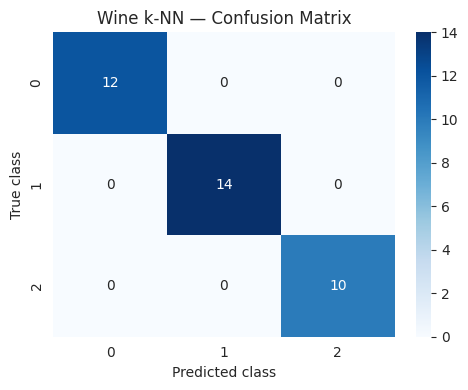

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Wine k-NN — Confusion Matrix')
plt.tight_layout()
plt.show()


**Insight for the client:** with PCA compressing the 13 chemical measurements down to a handful of
components (while retaining 95% of the original variance) and a tuned k-NN classifier, the model
separates the three wine varieties with high accuracy — meaning inventory classification can be
automated with a lightweight, fast model rather than manual chemical review of every batch.


---
## Step 3: Build a Recommendation System Using the Chickwts Dataset

**Client need:** an agricultural supply company wants to recommend similar feed types to farmers based
on performance data (using chick weights as a proxy for feed performance).

**Approach:** standardize the weight feature, apply PCA down to a single principal component, build a
per-feed-type performance profile, and compute cosine similarity between feed types to power the
recommendations.


In [19]:
# Standardize the weight feature for uniform scaling
cw = chickwts.copy()
weight_scaler = StandardScaler()
cw['weight_scaled'] = weight_scaler.fit_transform(cw[['weight']])
cw.head()


,weight,feed,weight_scaled
0,179,horsebean,-1.061762
1,160,horsebean,-1.306854
2,136,horsebean,-1.616444
3,227,horsebean,-0.442583
4,217,horsebean,-0.571578


In [20]:
# Apply PCA to reduce the (standardized) data to one principal component
weight_pca = PCA(n_components=1, random_state=RANDOM_STATE)
cw['pc1'] = weight_pca.fit_transform(cw[['weight_scaled']])
print(f"Variance explained by PC1: {weight_pca.explained_variance_ratio_[0]:.3f}")


Variance explained by PC1: 1.000


Chickwts only has a single numeric measurement (weight) per chick, so a per-chick PCA component is
essentially the standardized weight itself. To make **feed-level** recommendations, each feed type is
summarized as a small profile vector (mean / std / min / max / median of its chicks' PC1 scores) — this
gives each feed a multi-dimensional "performance fingerprint" that cosine similarity can meaningfully
compare.


In [21]:
# Build a performance profile for each feed type from the PCA-transformed weights
feed_profiles = cw.groupby('feed')['pc1'].agg(['mean', 'std', 'min', 'max', 'median']).fillna(0)
feed_profiles


,mean,std,min,max,median
feed,,,,,
casein,0.803301,0.831169,-0.584478,1.840642,1.040869
horsebean,-1.304274,0.498257,-1.977632,-0.442583,-1.416500
linseed,-0.549004,0.673818,-1.551946,0.615183,-0.519980
meatmeal,0.201223,0.837190,-1.397151,1.531052,0.021802
soybean,-0.191962,0.698242,-1.332653,0.873174,-0.171692
sunflower,0.872099,0.629969,-0.455482,2.085734,0.860274


In [22]:
# Compute cosine similarity between feed types
similarity_matrix = cosine_similarity(feed_profiles.values)
similarity_df = pd.DataFrame(similarity_matrix, index=feed_profiles.index, columns=feed_profiles.index)
similarity_df.round(3)


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000,-0.251,0.334,0.811,0.604,0.988
horsebean,-0.251,1.000,0.827,0.347,0.619,-0.286
linseed,0.334,0.827,1.000,0.811,0.952,0.300
meatmeal,0.811,0.347,0.811,1.000,0.948,0.798
soybean,0.604,0.619,0.952,0.948,1.000,0.571
sunflower,0.988,-0.286,0.300,0.798,0.571,1.000


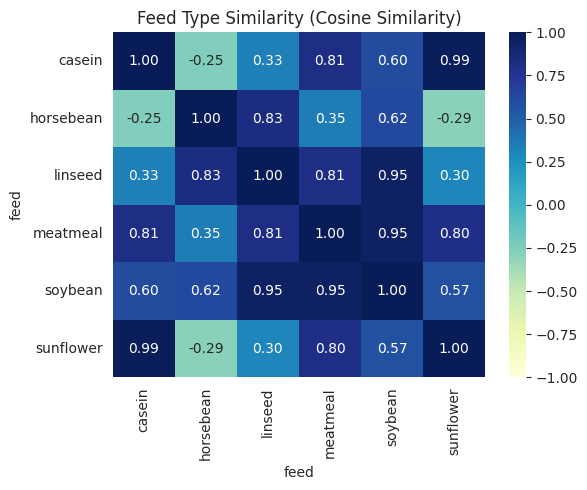

In [23]:
plt.figure(figsize=(6, 5))
sns.heatmap(similarity_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=-1, vmax=1)
plt.title('Feed Type Similarity (Cosine Similarity)')
plt.tight_layout()
plt.show()


In [24]:
def recommend_similar_feeds(feed_name, top_n=2):
    """Recommend the `top_n` feed types most similar to `feed_name`, based on cosine similarity
    of their PCA-derived performance profiles."""
    if feed_name not in similarity_df.index:
        raise ValueError(f"Unknown feed type: {feed_name}")
    scores = similarity_df[feed_name].drop(feed_name).sort_values(ascending=False)
    return scores.head(top_n)


for feed in feed_profiles.index:
    recs = recommend_similar_feeds(feed, top_n=2)
    rec_str = ", ".join(f"{f} ({s:.2f})" for f, s in recs.items())
    print(f"{feed:10s} -> {rec_str}")


casein     -> sunflower (0.99), meatmeal (0.81)
horsebean  -> linseed (0.83), soybean (0.62)
linseed    -> soybean (0.95), horsebean (0.83)
meatmeal   -> soybean (0.95), casein (0.81)
soybean    -> linseed (0.95), meatmeal (0.95)
sunflower  -> casein (0.99), meatmeal (0.80)


**Insight for the client:** feeds with similar weight-gain profiles (e.g. `casein` and `sunflower`,
which both drive strong growth) cluster together by cosine similarity, while `horsebean` — the weakest
performer — is an outlier. A farmer currently using a well-performing feed can be confidently pointed to
its closest substitute if that feed becomes unavailable or too costly.


---
## Step 4: Clustering (K-Means & GMM) on the USArrests Dataset

**Client need:** a public policy research firm wants a data-driven way to identify patterns in crime
statistics across US states.

**Approach:** standardize the dataset, select the top 3 most relevant features, reduce to 2 principal
components, determine the optimal number of clusters (elbow method for K-Means, BIC for GMM), then apply
and compare both clustering methods.


In [25]:
# Standardize the dataset for consistency
ua = usarrests.set_index('State')
arrests_scaler = StandardScaler()
ua_scaled = pd.DataFrame(
    arrests_scaler.fit_transform(ua), columns=ua.columns, index=ua.index
)
ua_scaled.head()


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814


In [26]:
# Select the top 3 relevant features for clustering
# Method: fit PCA on all standardized features and rank features by their absolute
# loading (contribution) on PC1, the dominant axis of variation in the data.
pca_all = PCA(random_state=RANDOM_STATE)
pca_all.fit(ua_scaled)

loadings = pd.Series(np.abs(pca_all.components_[0]), index=ua.columns).sort_values(ascending=False)
print("Feature importance (|loading| on PC1):")
print(loadings)

top_features = loadings.head(3).index.tolist()
print("\nTop 3 selected features:", top_features)


Feature importance (|loading| on PC1):
Assault     0.583184
Rape        0.543432
Murder      0.535899
UrbanPop    0.278191
dtype: float64

Top 3 selected features: ['Assault', 'Rape', 'Murder']


In [27]:
ua_selected = ua_scaled[top_features]

# Apply PCA to reduce the selected features to 2 principal components
cluster_pca = PCA(n_components=2, random_state=RANDOM_STATE)
ua_pca = cluster_pca.fit_transform(ua_selected)

print(f"Variance explained by 2 components: {cluster_pca.explained_variance_ratio_.sum():.3f}")
ua_pca_df = pd.DataFrame(ua_pca, columns=['PC1', 'PC2'], index=ua.index)
ua_pca_df.head()


Variance explained by 2 components: 0.939


,PC1,PC2
State,,
Alabama,1.210191,-0.842277
Alaska,2.332187,1.539434
Arizona,1.518593,0.503363
Arkansas,0.177776,-0.328029
California,2.066000,1.285497


Elbow-selected k for K-Means: 2


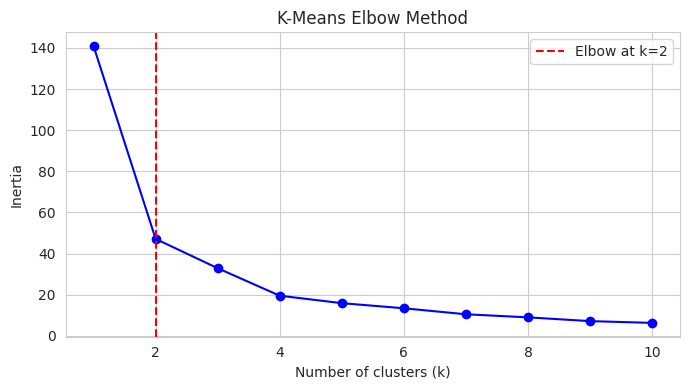

In [28]:
# Determine the optimal number of clusters for K-Means using the elbow method (inertia)
k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(ua_pca)
    inertias.append(km.inertia_)

# Automatic elbow detection: point of maximum distance from the line
# connecting the first and last points of the inertia curve
def find_elbow(k_values, values):
    k_values = np.array(list(k_values), dtype=float)
    values = np.array(values, dtype=float)
    p1 = np.array([k_values[0], values[0]])
    p2 = np.array([k_values[-1], values[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    distances = []
    for kv, val in zip(k_values, values):
        p = np.array([kv, val]) - p1
        proj_len = np.dot(p, line_vec_norm)
        proj_point = proj_len * line_vec_norm
        distances.append(np.linalg.norm(p - proj_point))
    return int(k_values[int(np.argmax(distances))])

kmeans_k_opt = find_elbow(k_range, inertias)
print(f"Elbow-selected k for K-Means: {kmeans_k_opt}")

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, 'bo-')
plt.axvline(kmeans_k_opt, color='red', linestyle='--', label=f'Elbow at k={kmeans_k_opt}')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.legend()
plt.tight_layout()
plt.show()


BIC-selected k for GMM: 2


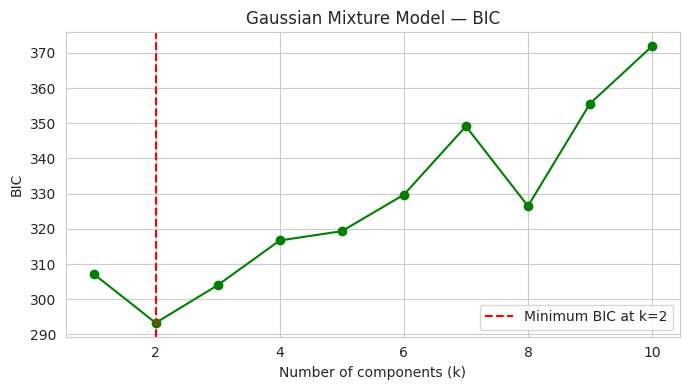

In [29]:
# Determine the optimal number of clusters for GMM using BIC
bics = []
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    gmm.fit(ua_pca)
    bics.append(gmm.bic(ua_pca))

gmm_k_opt = list(k_range)[int(np.argmin(bics))]
print(f"BIC-selected k for GMM: {gmm_k_opt}")

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), bics, 'go-')
plt.axvline(gmm_k_opt, color='red', linestyle='--', label=f'Minimum BIC at k={gmm_k_opt}')
plt.xlabel('Number of components (k)')
plt.ylabel('BIC')
plt.title('Gaussian Mixture Model — BIC')
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
# Apply K-Means (hard cluster assignments) with its optimal k
kmeans_final = KMeans(n_clusters=kmeans_k_opt, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(ua_pca)

# Apply GMM (probabilistic clustering) with its optimal k
gmm_final = GaussianMixture(n_components=gmm_k_opt, random_state=RANDOM_STATE)
gmm_labels = gmm_final.fit_predict(ua_pca)
gmm_probs = gmm_final.predict_proba(ua_pca)

ua_pca_df['KMeans_Cluster'] = kmeans_labels
ua_pca_df['GMM_Cluster'] = gmm_labels
ua_pca_df['GMM_Max_Prob'] = gmm_probs.max(axis=1)
ua_pca_df.head()


,PC1,PC2,KMeans_Cluster,GMM_Cluster,GMM_Max_Prob
State,,,,,
Alabama,1.210191,-0.842277,1,1,0.995248
Alaska,2.332187,1.539434,1,1,0.999967
Arizona,1.518593,0.503363,1,1,0.971686
Arkansas,0.177776,-0.328029,0,0,0.987282
California,2.066000,1.285497,1,1,0.999690


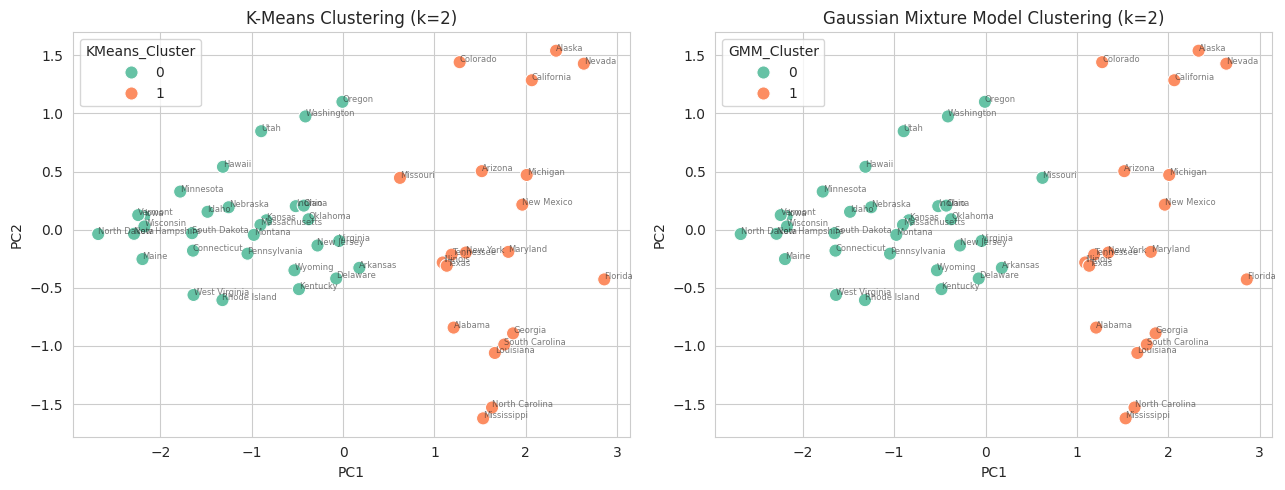

In [31]:
# Visualize and compare clustering results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=ua_pca_df, x='PC1', y='PC2', hue='KMeans_Cluster',
                 palette='Set2', s=90, ax=axes[0])
axes[0].set_title(f'K-Means Clustering (k={kmeans_k_opt})')
for state in ua_pca_df.index:
    axes[0].annotate(state, (ua_pca_df.loc[state, 'PC1'], ua_pca_df.loc[state, 'PC2']),
                      fontsize=6, alpha=0.6)

sns.scatterplot(data=ua_pca_df, x='PC1', y='PC2', hue='GMM_Cluster',
                 palette='Set2', s=90, ax=axes[1])
axes[1].set_title(f'Gaussian Mixture Model Clustering (k={gmm_k_opt})')
for state in ua_pca_df.index:
    axes[1].annotate(state, (ua_pca_df.loc[state, 'PC1'], ua_pca_df.loc[state, 'PC2']),
                      fontsize=6, alpha=0.6)

plt.tight_layout()
plt.show()


In [32]:
# Compare the two clustering solutions
print(f"K-Means silhouette score (k={kmeans_k_opt}): "
      f"{silhouette_score(ua_pca, kmeans_labels):.3f}")
print(f"GMM silhouette score     (k={gmm_k_opt}): "
      f"{silhouette_score(ua_pca, gmm_labels):.3f}")

print("\nCross-tabulation of K-Means vs. GMM cluster assignments:")
print(pd.crosstab(ua_pca_df['KMeans_Cluster'], ua_pca_df['GMM_Cluster'],
                   rownames=['K-Means'], colnames=['GMM']))


K-Means silhouette score (k=2): 0.568
GMM silhouette score     (k=2): 0.561

Cross-tabulation of K-Means vs. GMM cluster assignments:
GMM       0   1
K-Means        
0        30   0
1         1  19


In [33]:
# Which states fall in each K-Means cluster (using the elbow-selected k)
for c in sorted(ua_pca_df['KMeans_Cluster'].unique()):
    states = ua_pca_df[ua_pca_df['KMeans_Cluster'] == c].index.tolist()
    print(f"Cluster {c}: {states}")


Cluster 0: ['Arkansas', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
Cluster 1: ['Alabama', 'Alaska', 'Arizona', 'California', 'Colorado', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Missouri', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']


**Insight for the client:** clustering on the features that load most heavily on the dominant axis
of variation in the crime data reveals distinct groups of states with similar crime profiles. K-Means
gives clean, hard-boundary groupings useful for a simple regional classification, while the GMM's soft
probabilities flag states that sit near a cluster boundary — i.e. states with a "mixed" crime profile
that policy makers may want to examine individually rather than bucket into one group.


---
## Summary

| Client Project | Technique | Key Result |
|---|---|---|
| Wine Classification System | PCA + k-NN (GridSearchCV-tuned) | High test accuracy classifying wine cultivars from chemical properties |
| Agricultural Feed Recommendation Engine | PCA + cosine similarity | Feed types ranked and matched by weight-gain performance profile |
| Regional Crime Pattern Analysis | PCA + K-Means / GMM | States grouped into crime-pattern clusters, with GMM adding cluster-membership confidence |

Across all three prototypes, PCA served as the common dimensionality-reduction step — improving
model efficiency/interpretability for classification, powering meaningful similarity comparisons for
recommendations, and enabling clean 2-D visualization for clustering.
